LIBRARY YG  DI GUNAKAN

In [1]:
# Cell 1: Import Libraries
import cv2 
import os
import numpy as np 
import pandas as pd
import random
import joblib
import time  
from skimage.feature import graycomatrix, graycoprops
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [2]:
# Cell 2: Load Raw Data
dataset_dir = "kopi/"
raw_data = []

print("Memulai loading dataset paths...")

for folder in os.listdir(dataset_dir):
    folder_path = os.path.join(dataset_dir, folder)
    
    if not os.path.isdir(folder_path):
        continue
    
    if 'bagus' in folder.lower():
        class_label = 'Bagus'
    elif 'rusak' in folder.lower() or 'patah' in folder.lower():
        class_label = 'Rusak'
    elif 'jamur' in folder.lower():
        class_label = 'Jamur'
    else:
        continue
    
    print(f"📁 {folder} → {class_label}")
    
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.startswith('.') or not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                continue
            
            file_path = os.path.join(root, filename)
            raw_data.append({
                'path': file_path,
                'label': class_label
            })

print(f"\n✅ Total files loaded: {len(raw_data)}")
raw_df = pd.DataFrame(raw_data)
print(f"📊 Distribution: {raw_df['label'].value_counts().to_dict()}")

Memulai loading dataset paths...
📁 Bagus → Bagus
📁 Jamur → Jamur
📁 Rusak → Rusak

✅ Total files loaded: 740
📊 Distribution: {'Bagus': 286, 'Rusak': 240, 'Jamur': 214}


In [3]:
# Cell 3: Split Data
print("\n" + "="*60)
print("SPLIT DATA (Train/Val/Test)")
print("="*60)

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    raw_df['path'].values,
    raw_df['label'].values,
    test_size=0.4,
    random_state=42,
    stratify=raw_df['label'].values
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"\n📊 Pembagian Data:")
print(f"   Train: {len(train_paths)} images")
print(f"   Val:   {len(val_paths)} images")
print(f"   Test:  {len(test_paths)} images")
print(f"\n   Train distribution: {pd.Series(train_labels).value_counts().to_dict()}")
print(f"   Val distribution:   {pd.Series(val_labels).value_counts().to_dict()}")
print(f"   Test distribution:  {pd.Series(test_labels).value_counts().to_dict()}")


SPLIT DATA (Train/Val/Test)

📊 Pembagian Data:
   Train: 444 images
   Val:   148 images
   Test:  148 images

   Train distribution: {'Bagus': 172, 'Rusak': 144, 'Jamur': 128}
   Val distribution:   {'Bagus': 57, 'Rusak': 48, 'Jamur': 43}
   Test distribution:  {'Bagus': 57, 'Rusak': 48, 'Jamur': 43}


In [4]:
# Cell 4: Preprocessing Functions
def sharpen_image_fast(image):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(image, -1, kernel)
#  kernel = np.array([[-1, -1, -1],
#                        [-1,  9, -1],
#                        [-1, -1, -1]]) / 1.0
#     return cv2.filter2D(image, -1, kernel)

def reduce_blur_fast(image):
    denoised = cv2.medianBlur(image, 3)
    sharpened = sharpen_image_fast(denoised)
    return sharpened

def segment_image_otsu(img_gray):
    try:
        _, binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return binary
    except:
        return None

def load_and_preprocess_image(file_path):
    try:
        img_bgr = cv2.imread(file_path)
        if img_bgr is None:
            return None, None
        
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        img_rgb = cv2.resize(img_rgb, (400, 400))
        img_gray = cv2.resize(img_gray, (400, 400))
        
        img_gray = reduce_blur_fast(img_gray)
        
        return img_rgb, img_gray
    except:
        return None, None

print("✅ Preprocessing functions siap!")

✅ Preprocessing functions siap!


In [5]:
# Cell 5: Preprocessing Training Set
print("\n" + "="*60)
print("PREPROCESSING & SEGMENTASI - TRAINING SET")
print("="*60)

train_processed = []
start_time = time.time()

for i, (path, label) in enumerate(zip(train_paths, train_labels)):
    if (i + 1) % 50 == 0:
        print(f"Processing {i+1}/{len(train_paths)}...")
    
    img_rgb, img_gray = load_and_preprocess_image(path)
    
    if img_rgb is not None and img_gray is not None:
        binary = segment_image_otsu(img_gray)
        
        if binary is not None:
            train_processed.append({
                'original_gray': img_gray,
                'original_rgb': img_rgb,
                'otsu_binary': binary,
                'label': label
            })

print(f"✅ Train preprocessing complete: {len(train_processed)} images in {time.time()-start_time:.1f}s")


PREPROCESSING & SEGMENTASI - TRAINING SET


Processing 50/444...
Processing 100/444...
Processing 150/444...
Processing 200/444...
Processing 250/444...
Processing 300/444...
Processing 350/444...
Processing 400/444...
✅ Train preprocessing complete: 444 images in 109.5s


In [6]:
# Cell 6: Preprocessing Validation Set
print("\n" + "="*60)
print("PREPROCESSING & SEGMENTASI - VALIDATION SET")
print("="*60)

val_processed = []
start_time = time.time()

for i, (path, label) in enumerate(zip(val_paths, val_labels)):
    if (i + 1) % 50 == 0:
        print(f"Processing {i+1}/{len(val_paths)}...")
    
    img_rgb, img_gray = load_and_preprocess_image(path)
    
    if img_rgb is not None and img_gray is not None:
        binary = segment_image_otsu(img_gray)
        
        if binary is not None:
            val_processed.append({
                'original_gray': img_gray,
                'original_rgb': img_rgb,
                'otsu_binary': binary,
                'label': label
            })

print(f"✅ Val preprocessing complete: {len(val_processed)} images in {time.time()-start_time:.1f}s")


PREPROCESSING & SEGMENTASI - VALIDATION SET
Processing 50/148...
Processing 100/148...
✅ Val preprocessing complete: 148 images in 31.4s


In [7]:
# Cell 7: Preprocessing Test Set
print("\n" + "="*60)
print("PREPROCESSING & SEGMENTASI - TEST SET")
print("="*60)

test_processed = []
start_time = time.time()

for i, (path, label) in enumerate(zip(test_paths, test_labels)):
    if (i + 1) % 50 == 0:
        print(f"Processing {i+1}/{len(test_paths)}...")
    
    img_rgb, img_gray = load_and_preprocess_image(path)
    
    if img_rgb is not None and img_gray is not None:
        binary = segment_image_otsu(img_gray)
        
        if binary is not None:
            test_processed.append({
                'original_gray': img_gray,
                'original_rgb': img_rgb,
                'otsu_binary': binary,
                'label': label
            })

print(f"✅ Test preprocessing complete: {len(test_processed)} images in {time.time()-start_time:.1f}s")


PREPROCESSING & SEGMENTASI - TEST SET
Processing 50/148...
Processing 100/148...
✅ Test preprocessing complete: 148 images in 32.0s


In [8]:
# # Cell 8: Visualisasi Sample Data
# def display_random_samples_3class(processed_data, num_samples=6):
#     if len(processed_data) == 0:
#         print("❌ Tidak ada gambar untuk ditampilkan")
#         return
    
#     indices = random.sample(range(len(processed_data)), min(num_samples, len(processed_data)))
#     colors = {'Bagus': 'green', 'Rusak': 'red', 'Jamur': 'orange'}
    
#     plt.figure(figsize=(18, 8))
    
#     for i, idx in enumerate(indices):
#         data = processed_data[idx]
        
#         plt.subplot(2, num_samples, i + 1)
#         plt.imshow(data['original_gray'], cmap='gray')
#         plt.title(f"Gray - {data['label']}", 
#                  color=colors.get(data['label'], 'black'),
#                  fontweight='bold')
#         plt.axis('off')
        
#         plt.subplot(2, num_samples, i + 1 + num_samples)
#         plt.imshow(data['original_rgb'])
#         plt.title(f"RGB - {data['label']}", 
#                  color=colors.get(data['label'], 'black'),
#                  fontweight='bold')
#         plt.axis('off')
    
#     plt.suptitle("SAMPLE BIJI KOPI - TRAINING SET", 
#                 fontsize=20, fontweight='bold', y=0.98)
#     plt.tight_layout()
#     plt.show()

# if len(train_processed) > 0:
#     display_random_samples_3class(train_processed)

In [9]:
# # Cell 9: Visualisasi Segmentasi
# def display_segmentation_samples(segmented_data, num_samples=4):
#     indices = random.sample(range(len(segmented_data)), min(num_samples, len(segmented_data)))
    
#     plt.figure(figsize=(12, 8))
#     for i, idx in enumerate(indices):
#         data = segmented_data[idx]
        
#         plt.subplot(2, 4, i+1)
#         plt.imshow(data['original_gray'], cmap='gray')
#         plt.title(f"Original Gray\nStatus: {data['label']}", 
#                  color='green' if data['label']=="Bagus" else 'red' if data['label']=="Rusak" else 'orange')
#         plt.axis('off')
        
#         plt.subplot(2, 4, i+5)
#         plt.imshow(data['otsu_binary'], cmap='gray')
#         plt.title("Otsu Binary")
#         plt.axis('off')
    
#     plt.suptitle("HASIL SEGMENTASI OTSU BIJI KOPI", fontsize=16)
#     plt.tight_layout()
#     plt.show()

# if len(train_processed) > 0:
#     display_segmentation_samples(train_processed)


🎯 Menampilkan visualisasi preprocessing...
📸 VISUALISASI TAHAPAN PREPROCESSING - TRAINING PIPELINE
✅ TAHAP 1: Load Image
✅ TAHAP 2: Color Conversion
✅ Resize to 400x400
✅ Sharpening
✅ Denoising
✅ Sharpening and Denoising Completed
✅ TAHAP 7: Otsu Segmentation


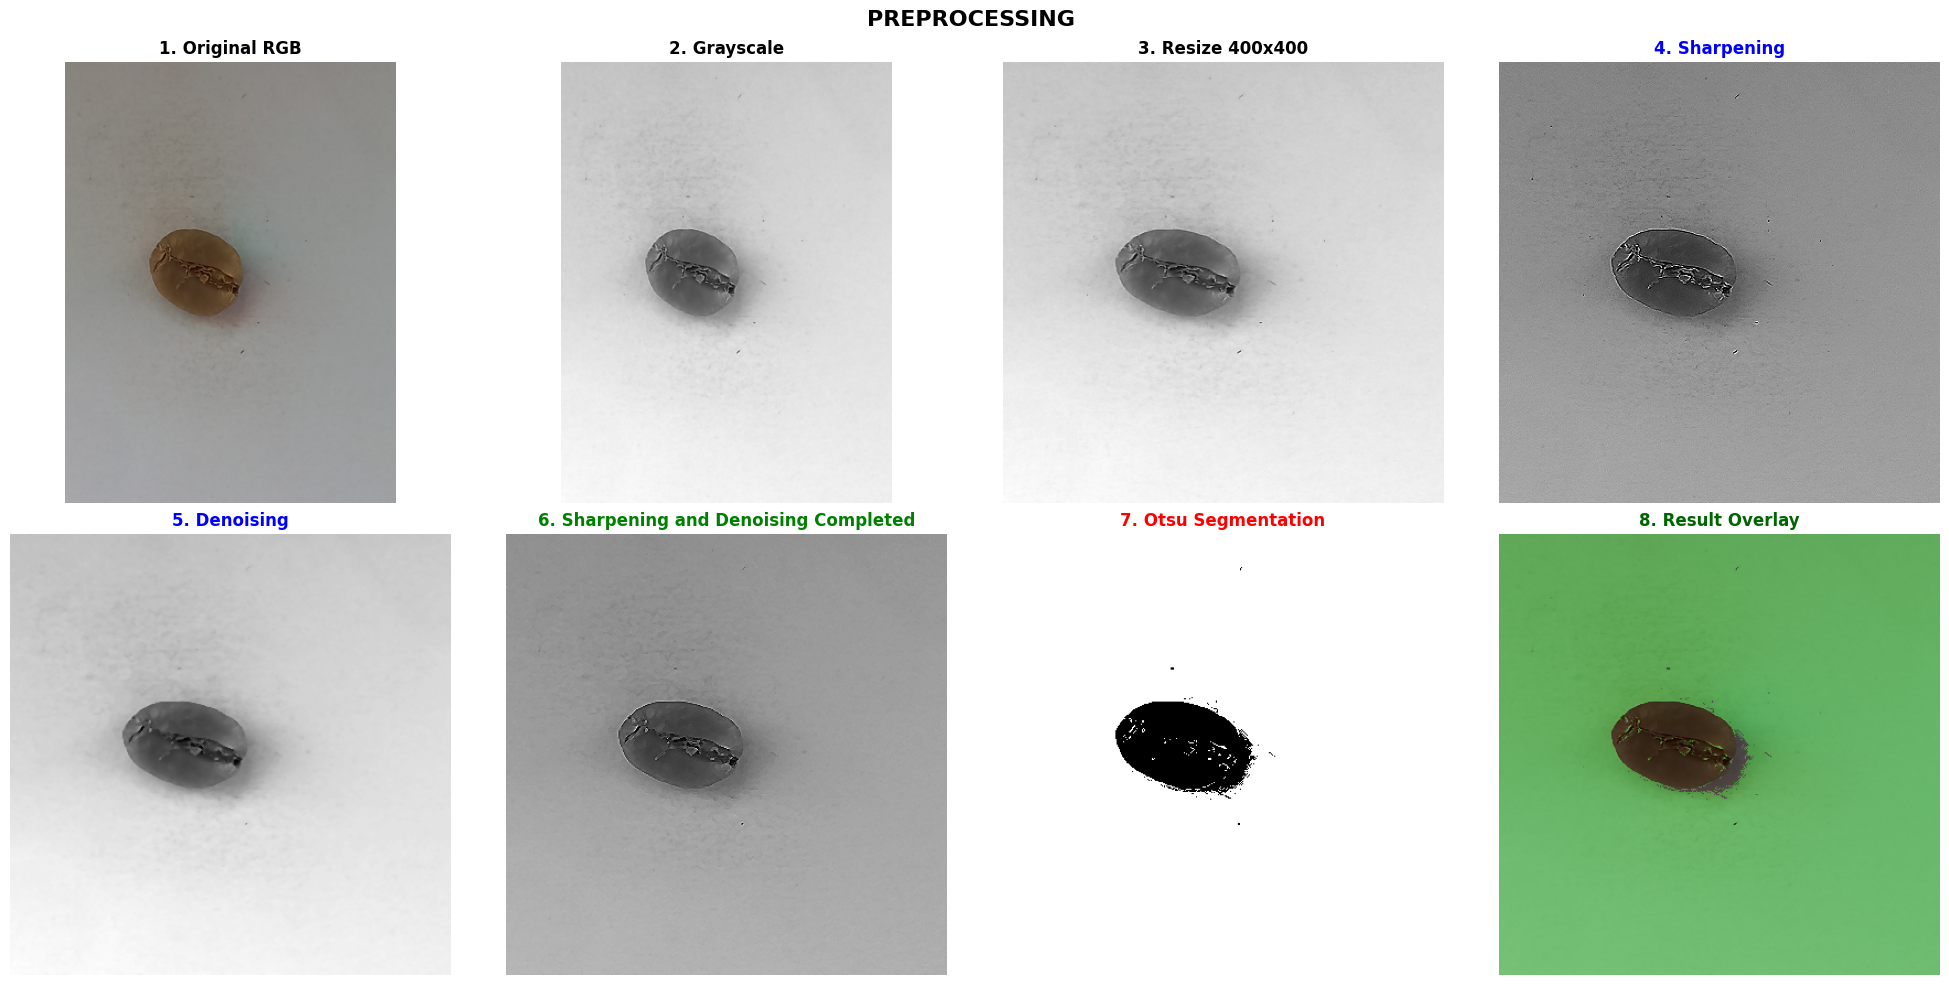

In [10]:
# Visualisasi Tahapan Preprocessing Training

def visualize_training_preprocessing(file_path):
    """
    Menampilkan SEMUA tahapan preprocessing yang terjadi saat training
    """
    print("="*70)
    print("📸 VISUALISASI TAHAPAN PREPROCESSING - TRAINING PIPELINE")
    print("="*70)
    
    try:
        # TAHAP 1: Load Original Image
        img_bgr = cv2.imread(file_path)
        if img_bgr is None:
            print("❌ Gagal membaca gambar")
            return
        
        print(f"✅ TAHAP 1: Load Image")
        
        # TAHAP 2: Convert to RGB dan Grayscale
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        print(f"✅ TAHAP 2: Color Conversion")
        
        # TAHAP 3: Resize
        img_rgb_before = img_rgb.copy()
        img_gray_before = img_gray.copy()
        
        img_rgb = cv2.resize(img_rgb, (400, 400))
        img_gray = cv2.resize(img_gray, (400, 400))
        
        print(f"✅ Resize to 400x400")
        
        # TAHAP 4: Sharpening
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        img_sharpened = cv2.filter2D(img_gray, -1, kernel)
        
        print(f"✅ Sharpening")
        
        # TAHAP 5: Denoising
        img_denoised = cv2.medianBlur(img_gray, 3)
        
        print(f"✅ Denoising")
        
        # TAHAP 6: Final (Denoise + Sharpen)
        img_final = cv2.filter2D(img_denoised, -1, kernel)
        
        print(f"✅ Sharpening and Denoising Completed")
        
        # TAHAP 7: Segmentasi Otsu
        _, img_otsu = cv2.threshold(img_final, 0, 255, 
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        print(f"✅ TAHAP 7: Otsu Segmentation")
        
        # VISUALISASI
        fig = plt.figure(figsize=(20, 10))
        
        plt.subplot(2, 4, 1)
        plt.imshow(img_rgb_before)
        plt.title("1. Original RGB", fontweight='bold')
        plt.axis('off')
        
        plt.subplot(2, 4, 2)
        plt.imshow(img_gray_before, cmap='gray')
        plt.title("2. Grayscale", fontweight='bold')
        plt.axis('off')
        
        plt.subplot(2, 4, 3)
        plt.imshow(img_gray, cmap='gray')
        plt.title("3. Resize 400x400", fontweight='bold')
        plt.axis('off')
        
        plt.subplot(2, 4, 4)
        plt.imshow(img_sharpened, cmap='gray')
        plt.title("4. Sharpening", fontweight='bold', color='blue')
        plt.axis('off')
        
        plt.subplot(2, 4, 5)
        plt.imshow(img_denoised, cmap='gray')
        plt.title("5. Denoising", fontweight='bold', color='blue')
        plt.axis('off')
        
        plt.subplot(2, 4, 6)
        plt.imshow(img_final, cmap='gray')
        plt.title("6. Sharpening and Denoising Completed", fontweight='bold', color='green')
        plt.axis('off')
        
        plt.subplot(2, 4, 7)
        plt.imshow(img_otsu, cmap='gray')
        plt.title("7. Otsu Segmentation", fontweight='bold', color='red')
        plt.axis('off')
        
        plt.subplot(2, 4, 8)
        overlay = img_rgb.copy()
        mask = np.zeros_like(img_rgb)
        mask[img_otsu > 0] = [0, 255, 0]
        result = cv2.addWeighted(overlay, 0.7, mask, 0.3, 0)
        plt.imshow(result)
        plt.title("8. Result Overlay", fontweight='bold', color='darkgreen')
        plt.axis('off')
        
        plt.suptitle('PREPROCESSING ', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error: {e}")

# JALANKAN VISUALISASI
if len(train_paths) > 0:
    print("\n🎯 Menampilkan visualisasi preprocessing...")
    sample_path = train_paths[0]
    visualize_training_preprocessing(sample_path)
    
    # # Tampilkan 2 sample lagi
    # if len(train_paths) > 1:
    #     visualize_training_preprocessing(train_paths[1])

In [11]:
# Cell 10: Ekstraksi Fitur
def extract_features_improved(segmented_imgs):
    features_list = []
    
    print("🔧 Mengekstraksi fitur...")
    
    for i, data in enumerate(segmented_imgs):
        img_gray = data['original_gray']
        img_rgb = data['original_rgb']
        binary_mask = data['otsu_binary']
        label = data['label']
        
        features = {}
        
        # COLOR FEATURES
        mask = binary_mask > 0
        if np.sum(mask) > 0:
            features['red_mean'] = np.mean(img_rgb[:, :, 0][mask])
            features['green_mean'] = np.mean(img_rgb[:, :, 1][mask])
            features['blue_mean'] = np.mean(img_rgb[:, :, 2][mask])
            
            img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
            features['hue_mean'] = np.mean(img_hsv[:, :, 0][mask])
            features['saturation_mean'] = np.mean(img_hsv[:, :, 1][mask])
            features['value_mean'] = np.mean(img_hsv[:, :, 2][mask])
        else:
            features.update({
                'red_mean': np.mean(img_rgb[:, :, 0]),
                'green_mean': np.mean(img_rgb[:, :, 1]),
                'blue_mean': np.mean(img_rgb[:, :, 2]),
                'hue_mean': 90, 'saturation_mean': 100, 'value_mean': 100
            })
        
        # TEXTURE FEATURES
        img_uint8 = img_gray.astype(np.uint8)
        glcm = graycomatrix(img_uint8, distances=[1, 3], angles=[0], 
                          levels=256, symmetric=True, normed=True)
        
        features['energy'] = np.mean(graycoprops(glcm, 'energy'))
        features['contrast'] = np.mean(graycoprops(glcm, 'contrast'))
        features['homogeneity'] = np.mean(graycoprops(glcm, 'homogeneity'))
        features['correlation'] = np.mean(graycoprops(glcm, 'correlation'))
        
        # SHAPE FEATURES
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            main_contour = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(main_contour)
            perimeter = cv2.arcLength(main_contour, True)
            
            features['area'] = area
            features['perimeter'] = perimeter
            
            if perimeter > 0:
                features['circularity'] = (4 * np.pi * area) / (perimeter ** 2)
            else:
                features['circularity'] = 0
        else:
            features.update({'area': 0, 'perimeter': 0, 'circularity': 0})
        
        # STATISTICAL FEATURES
        features['intensity_mean'] = np.mean(img_gray)
        features['intensity_std'] = np.std(img_gray)
        
        features['label'] = label
        features_list.append(features)
        
        if (i + 1) % 50 == 0:
            print(f"   Processed {i + 1}/{len(segmented_imgs)} images")
    
    return pd.DataFrame(features_list)

print("\n" + "="*60)
print("EKSTRAKSI FITUR - TRAINING SET")
print("="*60)
train_features = extract_features_improved(train_processed)

print("\n" + "="*60)
print("EKSTRAKSI FITUR - VALIDATION SET")
print("="*60)
val_features = extract_features_improved(val_processed)

print("\n" + "="*60)
print("EKSTRAKSI FITUR - TEST SET")
print("="*60)
test_features = extract_features_improved(test_processed)

print(f"\n✅ Feature extraction complete:")
print(f"   Train: {len(train_features)} samples")
print(f"   Val: {len(val_features)} samples")
print(f"   Test: {len(test_features)} samples")
print(f"   Features: {len(train_features.columns) - 1}")


EKSTRAKSI FITUR - TRAINING SET
🔧 Mengekstraksi fitur...
   Processed 50/444 images
   Processed 100/444 images
   Processed 150/444 images
   Processed 200/444 images
   Processed 250/444 images
   Processed 300/444 images
   Processed 350/444 images
   Processed 400/444 images

EKSTRAKSI FITUR - VALIDATION SET
🔧 Mengekstraksi fitur...
   Processed 50/148 images
   Processed 100/148 images

EKSTRAKSI FITUR - TEST SET
🔧 Mengekstraksi fitur...
   Processed 50/148 images
   Processed 100/148 images

✅ Feature extraction complete:
   Train: 444 samples
   Val: 148 samples
   Test: 148 samples
   Features: 15


In [12]:
# Cell 11: Persiapan Data Training
X_train = train_features.drop(['label'], axis=1)
y_train = train_features['label']

X_val = val_features.drop(['label'], axis=1)
y_val = val_features['label']

X_test = test_features.drop(['label'], axis=1)
y_test = test_features['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nPembagian data:")
print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")


Pembagian data:
Train: (444, 15), Val: (148, 15), Test: (148, 15)


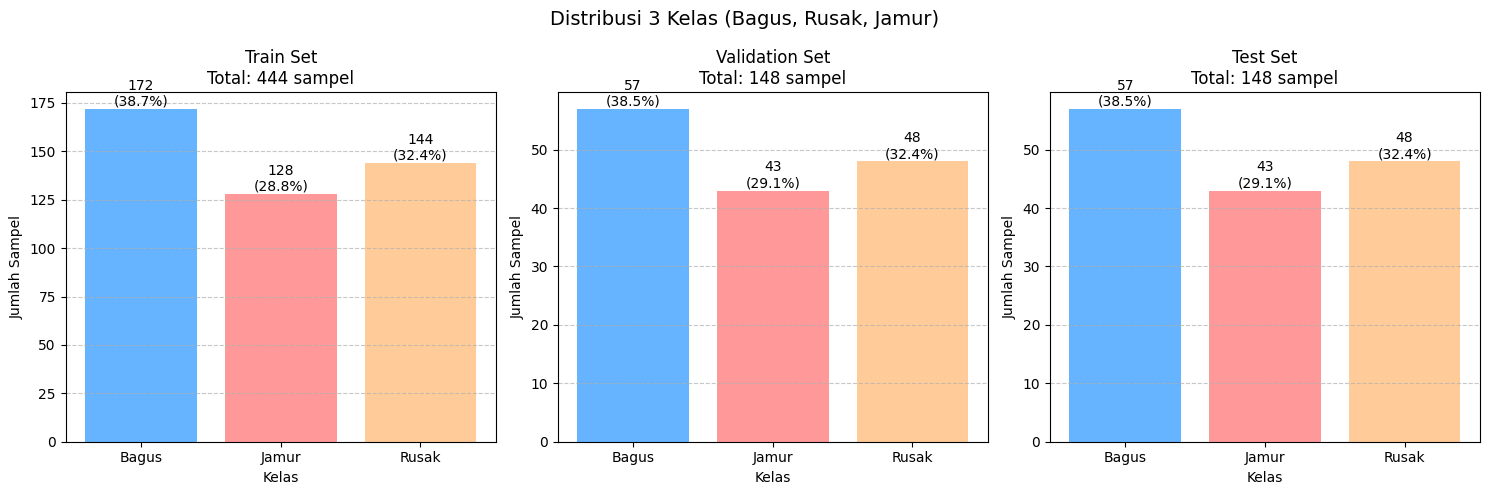

In [13]:
# Cell 12: Visualisasi Distribusi Data
def plot_3class_distribution(y_train, y_val, y_test):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    colors = ['#66b3ff', '#ff9999', '#ffcc99']
    
    for i, (y_data, title) in enumerate([(y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')]):
        counts = y_data.value_counts().sort_index()
        bars = ax[i].bar(range(len(counts)), counts.values, color=colors)
        ax[i].set_title(f'{title} Set\nTotal: {len(y_data)} sampel')
        ax[i].set_xlabel('Kelas')
        ax[i].set_ylabel('Jumlah Sampel')
        ax[i].set_xticks(range(len(counts)))
        ax[i].set_xticklabels(counts.index, rotation=0)
        ax[i].grid(axis='y', linestyle='--', alpha=0.7)
        
        for bar in bars:
            height = bar.get_height()
            ax[i].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height)}\n({height/len(y_data)*100:.1f}%)',
                      ha='center', va='bottom')
    
    plt.suptitle('Distribusi 3 Kelas (Bagus, Rusak, Jamur)', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_3class_distribution(y_train, y_val, y_test)

In [14]:
from sklearn.model_selection import GridSearchCV

# Definisikan rentang parameter yang ingin diuji
param_grid = {
    'C': [0.1, 1, 2, 3 ],  # Rentang yang umum untuk C
    'gamma': [0.001, 0.01, 0.1, 1], # Rentang yang umum untuk gamma
    'kernel': ['rbf']  # Kernel yang ingin diuji
}

# Inisialisasi GridSearchCV (misal menggunakan 5-fold cross-validation)
# 'scoring' disesuaikan jika data Anda tidak seimbang (misalnya 'f1_macro' atau 'f1_weighted')
grid_search = GridSearchCV(
    SVC(random_state=42, class_weight='balanced'), 
    param_grid, 
    cv=5, 
    scoring='accuracy', # Ganti ke metrik yang lebih sesuai jika perlu
    verbose=2
)

# Latih Grid Search pada data latih yang sudah di-*scaling*
grid_search.fit(X_train_scaled, y_train)

# Hasil terbaik
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("\nParameter Terbaik Ditemukan:")
print(best_params)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1

In [15]:
# Cell 13: Training Model SVM
print("\n" + "="*60)
print("TRAINING MODEL SVM")
print("="*60)

model = SVC(kernel='rbf', 
            C=2, gamma=0.1, 
            random_state=42, 
            probability=True,
            decision_function_shape='ovr',
            class_weight='balanced')

model.fit(X_train_scaled, y_train)
print("✅ Model berhasil dilatih!")


TRAINING MODEL SVM
✅ Model berhasil dilatih!


In [16]:
# Cell 14: Evaluasi Model
def evaluate_3class_model(model, X, y, set_name):
    y_pred = model.predict(X)
    
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{'='*50}")
    print(f"Evaluasi pada {set_name}:")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall:    {recall * 100:.2f}%")
    print(f"F1-Score:  {f1 * 100:.2f}%")
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

train_metrics = evaluate_3class_model(model, X_train_scaled, y_train, "Training")
val_metrics = evaluate_3class_model(model, X_val_scaled, y_val, "Validation")
test_metrics = evaluate_3class_model(model, X_test_scaled, y_test, "Test")


Evaluasi pada Training:
Accuracy:  94.37%
Precision: 94.41%
Recall:    94.37%
F1-Score:  94.35%

Evaluasi pada Validation:
Accuracy:  94.59%
Precision: 94.69%
Recall:    94.59%
F1-Score:  94.59%

Evaluasi pada Test:
Accuracy:  93.92%
Precision: 94.14%
Recall:    93.92%
F1-Score:  93.90%


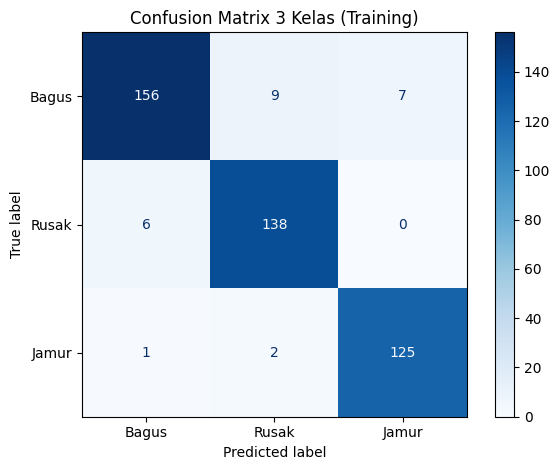

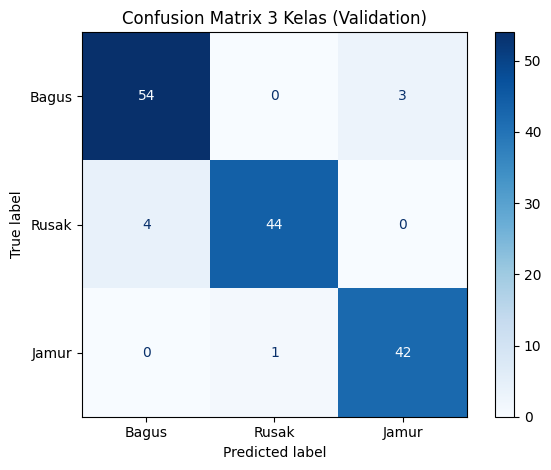

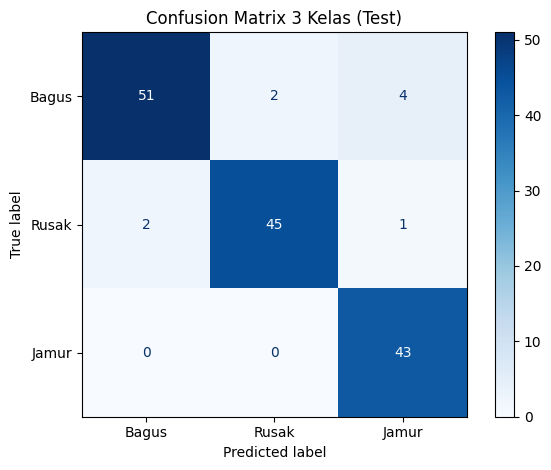

In [17]:
# Cell 15: Confusion Matrix
def plot_3class_confusion_matrix(y_true, y_pred, set_name):
    cm = confusion_matrix(y_true, y_pred, labels=['Bagus', 'Rusak', 'Jamur'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bagus', 'Rusak', 'Jamur'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix 3 Kelas ({set_name})')
    plt.tight_layout()
    plt.show()

plot_3class_confusion_matrix(y_train, model.predict(X_train_scaled), "Training")
plot_3class_confusion_matrix(y_val, model.predict(X_val_scaled), "Validation")
plot_3class_confusion_matrix(y_test, model.predict(X_test_scaled), "Test")

In [24]:
# Cell 16: Menyimpan Model
print("\nMenyimpan model dan scaler...")
joblib.dump(model, 'Model_SVM.pkl')
joblib.dump(scaler, 'Model_Scaler.pkl')

feature_names = [col for col in train_features.columns if col != 'label']
joblib.dump(feature_names, 'coffee_feature_names.pkl')

print("✅ Model, scaler, dan feature names berhasil disimpan!")


Menyimpan model dan scaler...
✅ Model, scaler, dan feature names berhasil disimpan!


# Prediksi Data Baru

In [19]:
# def classify_single_bean(image_path, model, scaler):
#     """Klasifikasi gambar dengan SATU BIJI KOPI"""
#     try:
#         img_bgr = cv2.imread(image_path)
#         if img_bgr is None:
#             return None, 0, None, None
        
#         img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#         img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
#         img_rgb = cv2.resize(img_rgb, (400, 400))
#         img_gray = cv2.resize(img_gray, (400, 400))
        
#         img_gray = reduce_blur_fast(img_gray)
#         binary = segment_image_otsu(img_gray)
        
#         data_for_features = [{
#             'original_gray': img_gray,
#             'original_rgb': img_rgb,
#             'otsu_binary': binary,
#             'label': 'Unknown'
#         }]
        
#         features_df = extract_features_improved(data_for_features)
        
#         if len(features_df) == 0:
#             return None, 0, None, None
        
#         features = features_df.drop('label', axis=1)
#         features_scaled = scaler.transform(features)
        
#         prediction = model.predict(features_scaled)[0]
#         probabilities = model.predict_proba(features_scaled)[0]
#         confidence = max(probabilities) * 100
        
#         return prediction, confidence, img_rgb, binary
        
#     except Exception as e:
#         print(f"Error in classify_single_bean: {e}")
#         return None, 0, None, None



In [20]:
# # %% [markdown]
# # FUNGSI DETEKSI MULTIPLE BEANS

# # %%
# def detect_multiple_beans(image_path, model, scaler, min_area=300, max_area=50000):
#     """Deteksi gambar dengan MULTIPLE BIJI KOPI"""
#     try:
#         img_bgr = cv2.imread(image_path)
#         if img_bgr is None:
#             return None, None
        
#         img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#         img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
#         scale_factor = 400 / max(img_gray.shape)
#         new_width = int(img_gray.shape[1] * scale_factor)
#         new_height = int(img_gray.shape[0] * scale_factor)
        
#         img_rgb_detection = cv2.resize(img_rgb, (new_width, new_height))
#         img_gray_detection = cv2.resize(img_gray, (new_width, new_height))
        
#         img_blur = cv2.GaussianBlur(img_gray_detection, (5, 5), 0)
        
#         binary_adaptive = cv2.adaptiveThreshold(
#             img_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
#             cv2.THRESH_BINARY_INV, 11, 2
#         )
        
#         _, binary_otsu = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
#         contours_adaptive, _ = cv2.findContours(binary_adaptive, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         contours_otsu, _ = cv2.findContours(binary_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
#         meaningful_adaptive = [c for c in contours_adaptive if min_area <= cv2.contourArea(c) <= max_area]
#         meaningful_otsu = [c for c in contours_otsu if min_area <= cv2.contourArea(c) <= max_area]
        
#         if len(meaningful_adaptive) >= len(meaningful_otsu):
#             binary_used = binary_adaptive
#             contours = contours_adaptive
#         else:
#             binary_used = binary_otsu
#             contours = contours_otsu
        
#         kernel = np.ones((3, 3), np.uint8)
#         binary_cleaned = cv2.morphologyEx(binary_used, cv2.MORPH_CLOSE, kernel)
#         binary_cleaned = cv2.morphologyEx(binary_cleaned, cv2.MORPH_OPEN, kernel)
        
#         contours, _ = cv2.findContours(binary_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
#         bean_results = []
#         img_display = img_rgb_detection.copy()
#         colors = {'Bagus': (0, 255, 0), 'Rusak': (255, 0, 0), 'Jamur': (255, 165, 0)}
        
#         print(f"🔍 Ditemukan {len(contours)} contours")
        
#         meaningful_contours = [c for c in contours if min_area <= cv2.contourArea(c) <= max_area]
        
#         if len(meaningful_contours) <= 1:
#             print("🟡 Gambar dideteksi sebagai SINGLE BEAN")
#             return [], None
        
#         print(f"🟢 Gambar dideteksi sebagai MULTIPLE BEANS - {len(meaningful_contours)} biji terdeteksi")
        
#         for i, contour in enumerate(meaningful_contours):
#             area = cv2.contourArea(contour)
            
#             if min_area <= area <= max_area:
#                 x, y, w, h = cv2.boundingRect(contour)
                
#                 padding = 8
#                 x1 = max(0, x - padding)
#                 y1 = max(0, y - padding)
#                 x2 = min(img_rgb_detection.shape[1], x + w + padding)
#                 y2 = min(img_rgb_detection.shape[0], y + h + padding)
                
#                 roi_rgb = img_rgb_detection[y1:y2, x1:x2]
#                 roi_gray = img_gray_detection[y1:y2, x1:x2]
                
#                 if roi_rgb.size == 0 or roi_gray.size == 0:
#                     continue
                
#                 roi_rgb_resized = cv2.resize(roi_rgb, (400, 400))
#                 roi_gray_resized = cv2.resize(roi_gray, (400, 400))
                
#                 roi_gray_processed = reduce_blur_fast(roi_gray_resized)
#                 roi_binary = segment_image_otsu(roi_gray_processed)
                
#                 roi_data = {
#                     'original_gray': roi_gray_processed,
#                     'original_rgb': roi_rgb_resized,
#                     'otsu_binary': roi_binary,
#                     'label': 'Unknown'
#                 }
                
#                 features_df = extract_features_improved([roi_data])
                
#                 if len(features_df) > 0:
#                     features = features_df.iloc[0].to_dict()
#                     feature_names = [col for col in features_df.columns if col != 'label']
#                     feature_vector = [features[name] for name in feature_names]
                    
#                     feature_scaled = scaler.transform([feature_vector])
#                     prediction = model.predict(feature_scaled)[0]
#                     probabilities = model.predict_proba(feature_scaled)[0]
#                     confidence = max(probabilities) * 100
                    
#                     if confidence > 60:
#                         bean_results.append({
#                             'bean_id': len(bean_results) + 1,
#                             'prediction': prediction,
#                             'confidence': confidence,
#                             'bbox': (x, y, w, h),
#                             'area': area,
#                             'is_single_bean': False
#                         })
                        
#                         color = colors.get(prediction, (255, 255, 255))
#                         cv2.rectangle(img_display, (x, y), (x+w, y+h), color, 2)
                        
#                         label_text = f"{prediction}({confidence:.0f}%)"
#                         cv2.putText(img_display, label_text, (x, y-10), 
#                                     cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
#         print(f"✅ Deteksi multiple beans selesai: {len(bean_results)} biji terdeteksi")
#         return bean_results, img_display
        
#     except Exception as e:
#         print(f"Error in detect_multiple_beans: {e}")
#         import traceback
#         traceback.print_exc()
#         return None, None


In [21]:
# # %% [markdown]
# # FUNGSI SMART ANALYSIS

# # %%
# def smart_coffee_analysis(image_path, model, scaler):
#     """
#     🎯 SMART ANALYSIS: Otomatis deteksi jenis gambar dan pilih fungsi yang tepat
#     - Single bean → classify_single_bean()
#     - Multiple beans → detect_multiple_beans()
#     """
#     print("=" * 60)
#     print("🤖 SMART COFFEE BEAN ANALYSIS")
#     print("=" * 60)
    
#     print("\n🔍 ANALISIS JENIS GAMBAR:")
    
#     bean_results, detection_img = detect_multiple_beans(image_path, model, scaler)
    
#     if bean_results is None:
#         print("❌ Gagal menganalisis gambar")
#         return None
    
#     if len(bean_results) <= 1:
#         print("🟡 DIAGNOSA: SINGLE BEAN DETECTED")
#         print("\n📊 HASIL KLASIFIKASI SINGLE BEAN:")
        
#         single_pred, single_conf, img_rgb, binary = classify_single_bean(image_path, model, scaler)
        
#         if single_pred:
#             print(f"   ✅ Kualitas: {single_pred}")
#             print(f"   ✅ Confidence: {single_conf:.1f}%")
            
#             plt.figure(figsize=(15, 5))
            
#             plt.subplot(1, 4, 1)
#             original_img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
#             plt.imshow(original_img)
#             plt.title("Gambar Asli", fontweight='bold')
#             plt.axis('off')
            
#             plt.subplot(1, 4, 2)
#             if img_rgb is not None:
#                 plt.imshow(img_rgb)
#                 plt.title(f"Preprocessed\n({single_pred})", fontweight='bold')
#             plt.axis('off')
            
#             plt.subplot(1, 4, 3)
#             if binary is not None:
#                 plt.imshow(binary, cmap='gray')
#                 plt.title("Segmentasi", fontweight='bold')
#             plt.axis('off')
            
#             plt.subplot(1, 4, 4)
#             color = 'green' if single_pred == 'Bagus' else 'red' if single_pred == 'Rusak' else 'orange'
#             plt.text(0.5, 0.5, f"Kualitas: {single_pred}\nConfidence: {single_conf:.1f}%", 
#                     fontsize=16, fontweight='bold', ha='center', va='center', color=color,
#                     bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray"))
#             plt.title("HASIL AKHIR", fontweight='bold')
#             plt.axis('off')
            
#             plt.tight_layout()
#             plt.show()
            
#             return {
#                 'analysis_type': 'SINGLE_BEAN',
#                 'prediction': single_pred,
#                 'confidence': single_conf,
#                 'bean_count': 1
#             }
#         else:
#             print("❌ Gagal melakukan klasifikasi single bean")
#             return None
            
#     else:
#         print("🟢 DIAGNOSA: MULTIPLE BEANS DETECTED")
#         print(f"\n🔍 HASIL DETEKSI MULTIPLE BEANS:")
#         print(f"   ✅ Total biji terdeteksi: {len(bean_results)}")
        
#         class_counts = {}
#         for res in bean_results:
#             class_name = res['prediction']
#             class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
#         print(f"   📈 Distribusi Kualitas:")
#         for class_name, count in class_counts.items():
#             percentage = (count / len(bean_results)) * 100
#             print(f"      - {class_name}: {count} biji ({percentage:.1f}%)")
        
#         plt.figure(figsize=(15, 5))
        
#         plt.subplot(1, 3, 1)
#         original_img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
#         plt.imshow(original_img)
#         plt.title("Gambar Asli", fontweight='bold')
#         plt.axis('off')
        
#         plt.subplot(1, 3, 2)
#         if detection_img is not None:
#             plt.imshow(detection_img)
#             plt.title(f"Deteksi: {len(bean_results)} biji", fontweight='bold')
#         plt.axis('off')
        
#         plt.subplot(1, 3, 3)
#         if class_counts:
#             labels = list(class_counts.keys())
#             counts = list(class_counts.values())
#             colors = ['#2ecc71', '#e74c3c', '#f39c12']
            
#             plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
#             plt.title("Distribusi Kualitas", fontweight='bold')
#         else:
#             plt.text(0.5, 0.5, "Tidak ada\nbiji terdeteksi", 
#                     ha='center', va='center', fontsize=12)
        
#         plt.tight_layout()
#         plt.show()
        
#         return {
#             'analysis_type': 'MULTIPLE_BEANS',
#             'bean_detections': bean_results,
#             'class_distribution': class_counts,
#             'total_beans': len(bean_results)
#         }

# # %% [markdown]
# # TESTING SMART ANALYSIS


In [22]:
# # %%
# # TEST SMART ANALYSIS
# def test_smart_analysis():
#     """Test smart analysis dengan berbagai jenis gambar"""
#     print("Loading model dan scaler...")
#     try:
#         model_loaded = joblib.load('coffee_quality_model_otsu.pkl')
#         scaler_loaded = joblib.load('coffee_quality_scaler_otsu.pkl')
#         print("✅ Model berhasil dimuat!")
        
#         test_image_path = r"D:\Sem 7\PP_AAA\Rampung\prediksi\0.jpg"
        
#         if not os.path.exists(test_image_path):
#             test_images = [
#                 "kopi/Bagus/biji_bagus (1).jpg",
#                 "kopi/Rusak/biji_rusak (1).jpg", 
#                 "kopi/Jamur/biji_jamur (1).jpg"
#             ]
#             for test_img in test_images:
#                 if os.path.exists(test_img):
#                     test_image_path = test_img
#                     break
        
#         if os.path.exists(test_image_path):
#             print(f"\n📁 Menganalisis: {test_image_path}")
            
#             results = smart_coffee_analysis(
#                 test_image_path, 
#                 model_loaded, 
#                 scaler_loaded
#             )
            
#             if results:
#                 print(f"\n🎯 HASIL AKHIR:")
#                 if results['analysis_type'] == 'SINGLE_BEAN':
#                     print(f"   Jenis Analisis: Single Bean")
#                     print(f"   Kualitas: {results['prediction']} ({results['confidence']:.1f}%)")
#                 else:
#                     print(f"   Jenis Analisis: Multiple Beans")
#                     print(f"   Total Biji: {results['total_beans']}")
#                     for class_name, count in results['class_distribution'].items():
#                         print(f"   {class_name}: {count} biji")
            
#         else:
#             print("❌ Tidak ada gambar test yang ditemukan!")
            
#     except FileNotFoundError:
#         print("❌ Model tidak ditemukan! Jalankan training terlebih dahulu.")
#     except Exception as e:
#         print(f"❌ Error: {e}")

# # Jalankan test
# test_smart_analysis()